# Removing ambient / contamination RNA from droplet scRNA-seq

Every droplet-based single-cell library is contaminated with **ambient
RNA** — cell-free transcripts that leak out of stressed or lysed cells
into the suspension and get co-encapsulated with real cells. This
"soup" is captured and sequenced alongside each cell's native
transcriptome, so **every cell barcode carries a background of
transcripts it never expressed**.

Left uncorrected, ambient RNA is not harmless noise:

- it **inflates marker genes** in cell types that never expressed them —
  a T-cell barcode picks up haemoglobin from lysed erythrocytes, a
  neuron picks up a glial marker;
- it **distorts differential expression** and cluster annotation, and
  produces phantom "doublet-like" or "low-quality" populations;
- it scales with the soup concentration, so it is worst exactly in the
  samples that are hardest to dissociate (tumours, brain, frozen
  tissue).

Several methods estimate and subtract this background:

- **SoupX** (Young & Behjati, *GigaScience* 2020) — reads the soup
  profile out of the **empty droplets** and subtracts a per-cell
  fraction.
- **DecontX** (Yang *et al.*, *Genome Biology* 2020) — a variational-EM
  model that needs a **clustered** matrix, no empty droplets required.
- **FastCAR** (Berg *et al.* 2023) — deterministic per-gene subtraction
  from the empty-droplet ambient profile.
- **scCDC** (Wang *et al.* 2024) — corrects **only** the
  Global-Contamination-causing Genes, deliberately conservative.
- **CellBender** (Fleming *et al.*, *Nature Methods* 2023) — a deep
  generative model; best overall in benchmarks but GPU-heavy.

`ov.pp.ambient` threads the four native, pip-installable backends
(`pysoupx`, `pydecontx`, `pyfastcar`, `pysccdc`) behind a single
`remove_ambient` dispatcher, and adds diagnostics that audit the
correction.

**Where this step belongs.** Ambient removal operates on **raw
counts**, so it runs **after cell calling** (you need the filtered
cells, and for SoupX / FastCAR also the empty droplets) and **before
normalization, HVG selection and clustering**. In this tutorial we
cluster first only because DecontX / scCDC need cluster labels — in a
real pipeline you would do a quick preliminary clustering, decontaminate,
then re-run the full downstream analysis on the cleaned counts.

## 1. Load a real raw 10x dataset

`ov.datasets.pbmc_raw_10x()` downloads the 10x Genomics **`pbmc_1k_v3`**
dataset (peripheral-blood mononuclear cells, Chromium 3' v3, processed
with Cell Ranger 3.0.0). With `raw_droplets=True` it returns **two**
AnnData objects:

- `cells` — the **filtered** real cells (1,222 cells x 15,300 genes,
  raw UMI counts in `.X`);
- `raw` — the **raw unfiltered** droplet matrix (13,222 droplets =
  the 1,222 cells **plus 12,000 empty droplets**).

SoupX and FastCAR build their soup profile from those empty droplets, so
they need the `raw` object; DecontX and scCDC work from the filtered,
clustered cells alone.

In [1]:
import omicverse as ov
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
cells, raw = ov.datasets.pbmc_raw_10x(raw_droplets=True)
cells, raw

🔍 Downloading data to ./data/pbmc_raw_10x_cells.h5ad
⚠️ File ./data/pbmc_raw_10x_cells.h5ad already exists
🔍 Downloading data to ./data/pbmc_raw_10x_raw.h5ad
⚠️ File ./data/pbmc_raw_10x_raw.h5ad already exists


(AnnData object with n_obs × n_vars = 1222 × 15300
     obs: 'n_counts', 'n_genes'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'dataset',
 AnnData object with n_obs × n_vars = 13222 × 15300
     obs: 'droplet_type', 'n_counts'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'dataset')

In [3]:
# the raw matrix mixes real cells and empty droplets
raw.obs['droplet_type'].value_counts()

droplet_type
empty    12000
cell      1222
Name: count, dtype: int64

### The barcode-rank plot

The classic way to *see* the soup is the **barcode-rank plot**: total
UMIs per droplet, sorted from highest to lowest on a log-log scale. Real
cells sit on the high plateau; the long low tail is empty droplets that
contain **only ambient RNA** — that tail is the soup profile SoupX and
FastCAR estimate from.

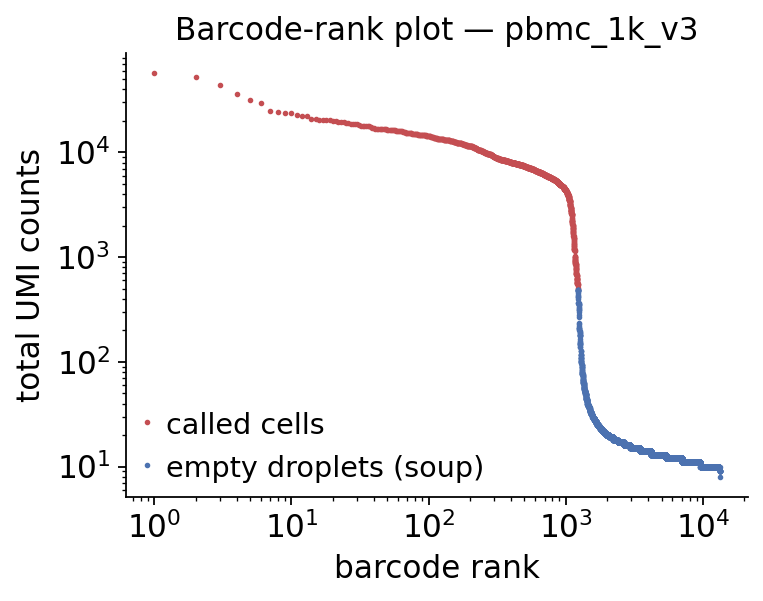

In [4]:
counts = np.asarray(raw.X.sum(axis=1)).ravel()
order = np.argsort(counts)[::-1]
is_cell = (raw.obs['droplet_type'] == 'cell').to_numpy()[order]

fig, ax = plt.subplots(figsize=(5, 4))
rank = np.arange(1, len(counts) + 1)
ax.loglog(rank[is_cell], counts[order][is_cell], '.', ms=3,
          color='#C44E52', label='called cells')
ax.loglog(rank[~is_cell], counts[order][~is_cell], '.', ms=3,
          color='#4C72B0', label='empty droplets (soup)')
ax.set_xlabel('barcode rank')
ax.set_ylabel('total UMI counts')
ax.set_title('Barcode-rank plot — pbmc_1k_v3')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 2. A quick clustering

DecontX and scCDC need cluster labels, and SoupX uses them to
auto-estimate the contamination fraction. We run a standard omicverse
preprocessing + Leiden pipeline on a **working copy**, then transfer the
labels and the UMAP back onto the raw-count `cells` object — ambient
removal must operate on **raw counts across all genes**, not on the
log-normalised HVG subset.

In [5]:
work = cells.copy()
work = ov.pp.preprocess(work, mode='shiftlog|pearson', n_HVGs=2000)
work.raw = work
work = work[:, work.var.highly_variable_features].copy()

🔍 [2026-05-22 00:17:46] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 15300/15300 genes are kept.
    Among 15300 genes, 15300 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 5 highly-expressed genes from normalization computation
   Excluded genes: ['IGKC', 'HBB', 'MALAT1', 'MT-CO1', 'MT-CO3']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,222 cells × 15,300 genes
   ✓ Runtime: 0.07s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 15,300 total (13.1%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.31 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

In [6]:
ov.pp.scale(work)
ov.pp.pca(work, layer='scaled', n_pcs=30)
ov.pp.neighbors(work, n_neighbors=15, n_pcs=30, use_rep='scaled|original|X_pca')
ov.pp.leiden(work, resolution=1.0)
ov.pp.umap(work)


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.0259s                                                 │
│  Shape:    1,222 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 1222x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (1222, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (5.87s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 5.8701s                                                 │
│  Shape:    1,222 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 1222x30)                               │
│           │ ✚ scaled|original|X_pca (array, 1222x30)               │
│         

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 1,222 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 11.3594s                                                │
│  Shape:    1,222 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 1,222 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.794s                                                  │
│  Shape:    1,222 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 1222x2)                               │
│                 

In [7]:
# transfer the cluster labels + embedding onto the raw-count AnnData
cells.obs['leiden'] = work.obs['leiden'].values
cells.obsm['X_umap'] = work.obsm['X_umap']
cells.obs['leiden'].value_counts()

leiden
0     224
1     182
2     125
3     122
4     108
5      72
6      69
7      64
8      63
9      57
10     54
11     47
12     35
Name: count, dtype: int64

## 3. Run `remove_ambient` with each native method

`ov.pp.ambient.remove_ambient` is a single `method=` dispatcher. It
writes the decontaminated counts back into `.X`, keeps the original
counts in `layers['ambient_raw']`, stores the per-cell contamination
fraction in `obs['ambient_contamination']`, and records method metadata
in `uns['ambient']`.

- **SoupX / FastCAR** need the raw unfiltered matrix — pass `raw=`.
- **DecontX / scCDC** need cluster labels — pass `cluster_key=`.

We run all four on independent copies so we can compare them.

In [8]:
ad_soupx = cells.copy()
ov.pp.ambient.remove_ambient(ad_soupx, method='soupx', raw=raw,
                             cluster_key='leiden', verbose=True)

773 genes passed tf-idf cut-off and 103 soup quantile filter. Taking the top 100.
Using 952 independent estimates of rho.


Estimated global rho of 0.01


[ov.pp.ambient] method=soupx  mean contamination=0.0100  genes corrected=15300


AnnData object with n_obs × n_vars = 1222 × 15300
    obs: 'n_counts', 'n_genes', 'leiden', 'ambient_contamination'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'dataset', 'ambient'
    obsm: 'X_umap'
    layers: 'ambient_raw'

In [9]:
ad_decontx = cells.copy()
ov.pp.ambient.remove_ambient(ad_decontx, method='decontx',
                             cluster_key='leiden', verbose=True)

DecontX: analysing batch 'all_cells' (1222 cells)


  iter 10 | converge: 0.03146


  iter 20 | converge: 0.0201


  iter 30 | converge: 0.009111


  iter 40 | converge: 0.004174


...

  iter 90 | converge: 0.00159


  iter 100 | converge: 0.001244


  iter 110 | converge: 0.001005
  iter 111 | converge: 0.001


[ov.pp.ambient] method=decontx  mean contamination=0.0856  genes corrected=15300


AnnData object with n_obs × n_vars = 1222 × 15300
    obs: 'n_counts', 'n_genes', 'leiden', 'ambient_contamination'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'dataset', 'ambient'
    obsm: 'X_umap'
    layers: 'ambient_raw'

In [10]:
ad_fastcar = cells.copy()
ov.pp.ambient.remove_ambient(ad_fastcar, method='fastcar', raw=raw,
                             verbose=True)

[ov.pp.ambient] method=fastcar  mean contamination=0.0941  genes corrected=247


AnnData object with n_obs × n_vars = 1222 × 15300
    obs: 'n_counts', 'n_genes', 'leiden', 'ambient_contamination'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'dataset', 'ambient'
    obsm: 'X_umap'
    layers: 'ambient_raw'

In [11]:
ad_sccdc = cells.copy()
ov.pp.ambient.remove_ambient(ad_sccdc, method='sccdc',
                             cluster_key='leiden', verbose=True)

[ov.pp.ambient] method=sccdc  mean contamination=0.1317  genes corrected=59


AnnData object with n_obs × n_vars = 1222 × 15300
    obs: 'n_counts', 'n_genes', 'leiden', 'ambient_contamination'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'dataset', 'ambient'
    obsm: 'X_umap'
    layers: 'ambient_raw'

### Per-cell contamination fraction

Each run populates `obs['ambient_contamination']`. The four methods make
different modelling assumptions, so they will *not* agree on a single
number — that disagreement is itself informative, and the diagnostics
below let us judge the corrections rather than trust them blindly.

In [12]:
import pandas as pd
summary = pd.DataFrame({
    'soupx':   [ad_soupx.uns['ambient']['contamination_fraction']],
    'decontx': [ad_decontx.uns['ambient']['contamination_fraction']],
    'fastcar': [ad_fastcar.uns['ambient']['contamination_fraction']],
    'sccdc':   [ad_sccdc.uns['ambient']['contamination_fraction']],
}, index=['mean contamination fraction'])
summary.T

,mean contamination fraction
soupx,0.010000
decontx,0.085641
fastcar,0.094148
sccdc,0.131743


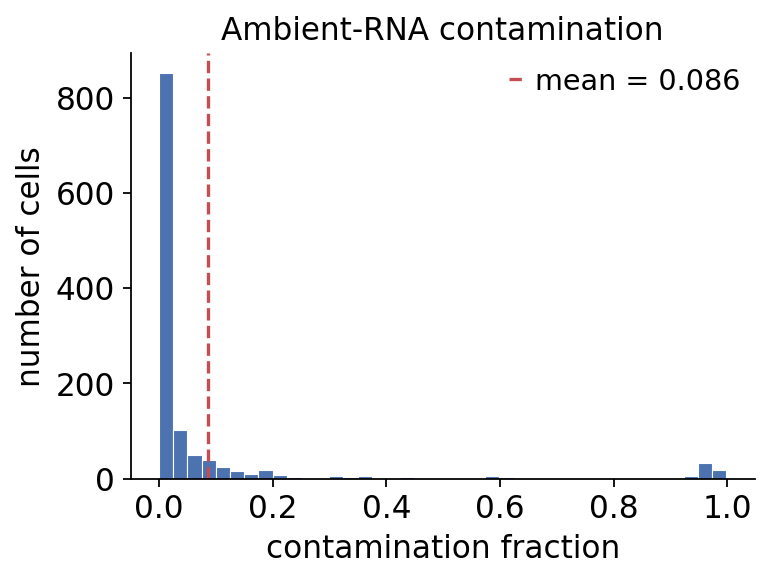

In [13]:
# distribution of the per-cell contamination fraction (DecontX run)
ov.pp.ambient.plot_contamination(ad_decontx)
plt.show()

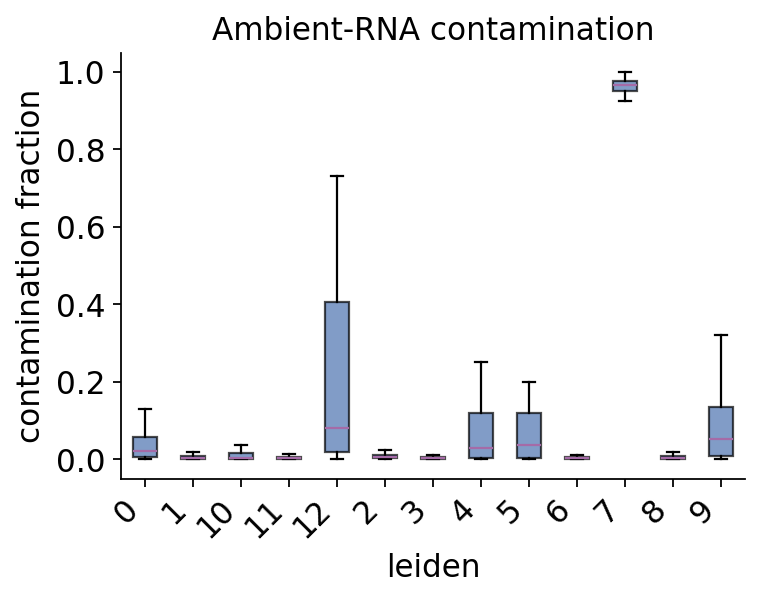

In [14]:
# contamination tends to track cell type — show it per Leiden cluster
ov.pp.ambient.plot_contamination(ad_decontx, groupby='leiden')
plt.show()

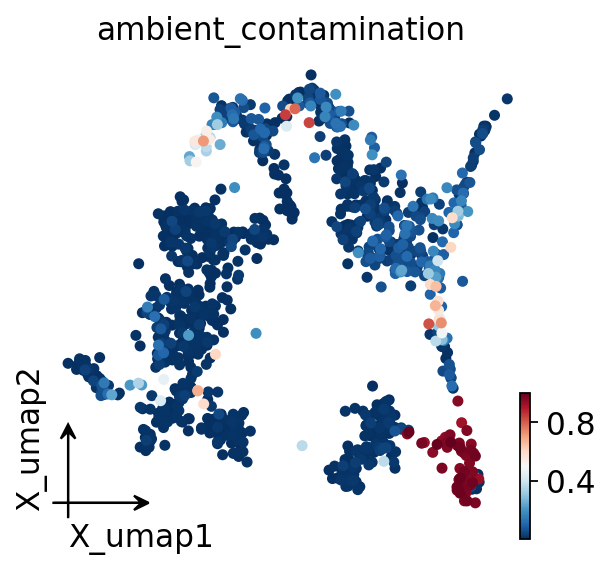

In [15]:
# overlay the contamination fraction on the UMAP
ov.pl.embedding(ad_decontx, basis='X_umap', color='ambient_contamination',
                frameon='small', show=False)
plt.show()

### Corrected vs raw counts

The decontaminated counts are now in `.X`; the originals are preserved
in `layers['ambient_raw']`. The total UMIs only ever go **down** —
ambient removal subtracts, it never adds.

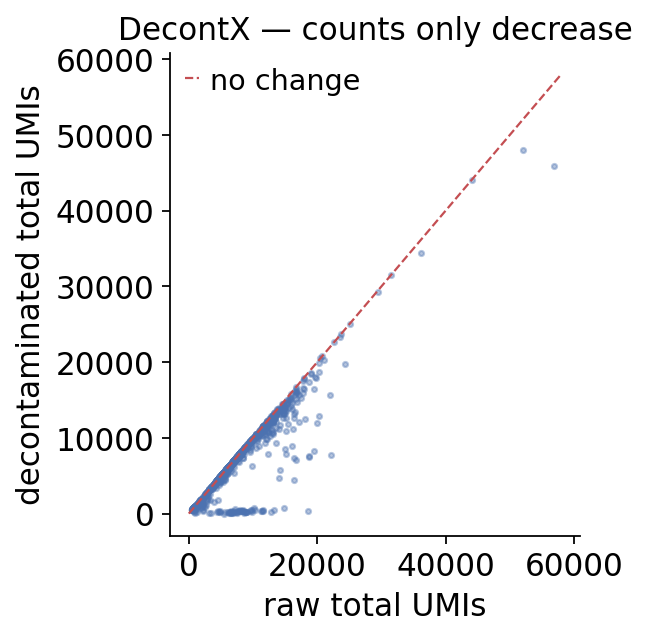

In [16]:
raw_tot = np.asarray(ad_decontx.layers['ambient_raw'].sum(axis=1)).ravel()
cor_tot = np.asarray(ad_decontx.X.sum(axis=1)).ravel()

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(raw_tot, cor_tot, s=5, alpha=0.4, color='#4C72B0')
lim = [0, raw_tot.max() * 1.02]
ax.plot(lim, lim, '--', color='#C44E52', lw=1, label='no change')
ax.set_xlabel('raw total UMIs')
ax.set_ylabel('decontaminated total UMIs')
ax.set_title('DecontX — counts only decrease')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Diagnostics

`ov.pp.ambient` ships read-only audits that check whether a correction
behaved sensibly — they do not modify the data.

### 4.1 Negative-marker check

A correct decontamination should drive a **cell-type-specific marker**
back toward zero in the cell types that biologically do **not** express
it. Haemoglobin **HBB** is the textbook example: it is hugely expressed
in erythrocytes/platelet contamination and leaks into every other
barcode as soup. `ambient_negative_marker_check` compares the raw vs
corrected mean of HBB across cell types and reports the fold reduction
in the cell types that should be HBB-negative.

In [17]:
hbb = ov.pp.ambient.ambient_negative_marker_check(
    ad_decontx, 'HBB', 'leiden')
hbb[['n_cells', 'raw_mean', 'corrected_mean', 'fold_reduction']].round(3)

,n_cells,raw_mean,corrected_mean,fold_reduction
celltype,,,,
0,224,0.000,0.000,inf
2,125,0.000,0.000,inf
8,63,0.000,0.000,inf
1,182,0.049,0.047,1.057000e+00
7,64,0.016,0.000,7.470206e+16
11,47,0.000,0.000,inf
6,69,0.000,0.000,inf
9,57,0.000,0.000,inf
4,108,4.056,4.056,1.000000e+00


In [18]:
# the aggregate over the HBB-negative cell types
hbb.attrs['summary']

{'marker': 'HBB',
 'positive_celltypes': ['4'],
 'n_negative_celltypes': 12,
 'neg_raw_mean': 0.0054229625190297765,
 'neg_corrected_mean': 0.0038977974782859297,
 'neg_fold_reduction': 1.3912889392638592}

The positive cell type (highest raw HBB — the erythroid/platelet
cluster) keeps its HBB, while the HBB-negative cell types see their
residual haemoglobin signal pushed down. That is exactly the behaviour
ambient removal should produce: soup stripped, biology preserved.

### 4.2 Count-integrity check

A trustworthy correction only **subtracts**: no matrix entry may grow,
and only the contaminated genes should change at all.
`count_integrity_check` verifies this against the 2026 ambient-RNA
benchmark count-integrity criterion.

In [19]:
integ = ov.pp.ambient.count_integrity_check(
    ad_decontx.layers['ambient_raw'], ad_decontx.X)
integ

{'passed': True,
 'n_entries': 18696600,
 'n_increased': 0,
 'max_increase': 0.0,
 'n_unchanged': 16203657,
 'frac_unchanged': 0.8666632970700555,
 'frac_changed': 0.13333670292994448,
 'total_raw': 9230791.0,
 'total_corrected': 8344633.546892991,
 'total_removed': 886157.4531070087,
 'removed_fraction': 0.09600016435287168}

### 4.3 Contamination report

`contamination_report` reads the metadata `remove_ambient` wrote into
`obs` / `uns` and returns a compact one-row summary per method.

In [20]:
report = pd.concat([
    ov.pp.ambient.contamination_report(ad_soupx),
    ov.pp.ambient.contamination_report(ad_decontx),
    ov.pp.ambient.contamination_report(ad_fastcar),
    ov.pp.ambient.contamination_report(ad_sccdc),
], ignore_index=True)
report

,method,n_cells,n_genes,genes_corrected,mean_contamination,median_contamination,min_contamination,max_contamination,integrity_passed,removed_fraction,frac_genes_changed
0,soupx,1222,15300,15300,0.010000,0.010000,0.010000,0.010000,True,0.010000,0.126952
1,decontx,1222,15300,15300,0.085641,0.007672,0.000039,0.998265,True,0.096000,0.133337
2,fastcar,1222,15300,247,0.094148,0.083521,0.009843,0.382253,True,0.070733,0.013277
3,sccdc,1222,15300,59,0.131743,0.103346,0.001969,0.802548,True,0.094104,0.003494


## 5. Ground-truth validation on a species-mixing dataset

On real PBMCs we have no ground truth for the soup — we can only check
that the correction behaves sensibly. The **human-mouse species-mixing
("barnyard") experiment** removes that ambiguity.

`ov.datasets.hgmm_mixture()` loads the 10x **`hgmm_1k_v3`** dataset: a
1:1 mix of human (HEK293T) and mouse (NIH3T3) cells, sequenced against a
combined `hg19 + mm10` reference. Because the two species share no
genes, **any transcript mapped to the *other* species inside a cell is
unambiguous ambient contamination**. The per-cell minor-species read
fraction is therefore a direct, label-free measure of soup — and a real
correction must reduce it.

In [21]:
hg_cells, hg_raw = ov.datasets.hgmm_mixture(raw_droplets=True)
hg_cells.obs['species'].value_counts()

🔍 Downloading data to ./data/hgmm_mixture_cells.h5ad
⚠️ File ./data/hgmm_mixture_cells.h5ad already exists
🔍 Downloading data to ./data/hgmm_mixture_raw.h5ad
⚠️ File ./data/hgmm_mixture_raw.h5ad already exists


species
mouse    544
human    495
mixed      7
Name: count, dtype: int64

We split the genes by genome (`hg19` vs `mm10`) and define the
**cross-species fraction** of a count matrix as the minor-species share
of each cell's reads — `min(human_frac, mouse_frac)`. With the genome
masks fixed, this is a short vectorised expression we reuse for the raw
matrix and for each decontaminated matrix.

In [22]:
# genome masks — fixed once, the soup measurement reuses them
genome = hg_cells.var['genome'].to_numpy()
hg_mask = genome == 'hg19'
mm_mask = genome == 'mm10'
print(f'{hg_mask.sum()} human (hg19) genes, {mm_mask.sum()} mouse (mm10) genes')

16122 human (hg19) genes, 13862 mouse (mm10) genes


In [23]:
# ground-truth contamination of the RAW counts: minor-species read fraction
hg_umi = np.asarray(hg_cells.X[:, hg_mask].sum(axis=1)).ravel()
mm_umi = np.asarray(hg_cells.X[:, mm_mask].sum(axis=1)).ravel()
hg_frac = hg_umi / np.maximum(hg_umi + mm_umi, 1)
gt_raw = np.minimum(hg_frac, 1.0 - hg_frac)
print(f'ground-truth mean cross-species fraction: {gt_raw.mean():.4f}')
print(f'                            median:       {np.median(gt_raw):.4f}')

ground-truth mean cross-species fraction: 0.0075
                            median:       0.0045


Roughly **0.75 %** of every cell's reads come from the wrong species —
that is the ambient contamination, measured without any model. Now we
cluster the cells (the two species form cleanly separated clusters),
run each backend, and recompute the cross-species fraction from the
**decontaminated** counts.

In [24]:
hg_work = hg_cells.copy()
hg_work = ov.pp.preprocess(hg_work, mode='shiftlog|pearson', n_HVGs=2000)
hg_work.raw = hg_work
hg_work = hg_work[:, hg_work.var.highly_variable_features].copy()
ov.pp.scale(hg_work)
ov.pp.pca(hg_work, layer='scaled', n_pcs=30)
ov.pp.neighbors(hg_work, n_neighbors=15, n_pcs=30,
                use_rep='scaled|original|X_pca')
ov.pp.leiden(hg_work, resolution=0.5)
hg_cells.obs['leiden'] = hg_work.obs['leiden'].values

🔍 [2026-05-22 00:18:46] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 29984/29984 genes are kept.
    Among 29984 genes, 29984 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson



🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 4 highly-expressed genes from normalization computation
   Excluded genes: ['hg19_MT-CO2', 'mm10_mt-Nd2', 'mm10_mt-Nd4', 'mm10_mt-Cytb']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,046 cells × 29,984 genes
   ✓ Runtime: 0.11s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 29,984 total (6.7%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.97 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ────────────────────

   🔧 PCA solver used: covariance_eigh
    finished✅ (1.94s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.9419s                                                 │
│  Shape:    1,046 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 1046x30)                               │
│           │ ✚ scaled|original|X_pca (array, 1046x30)               │
│         

   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 1,046 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 0.2066s                                                 │
│  Shape:    1,046 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit

In [25]:
# decontaminate with each native method and measure the residual soup
gt = {'raw (no correction)': gt_raw.mean()}
for method in ['soupx', 'decontx', 'fastcar', 'sccdc']:
    a = hg_cells.copy()
    if method in ('soupx', 'fastcar'):
        ov.pp.ambient.remove_ambient(a, method=method, raw=hg_raw,
                                     cluster_key='leiden')
    else:
        ov.pp.ambient.remove_ambient(a, method=method,
                                     cluster_key='leiden')
    hg_c = np.asarray(a.X[:, hg_mask].sum(axis=1)).ravel()
    mm_c = np.asarray(a.X[:, mm_mask].sum(axis=1)).ravel()
    f = hg_c / np.maximum(hg_c + mm_c, 1)
    gt[method] = float(np.minimum(f, 1.0 - f).mean())

gt_df = pd.DataFrame({'mean cross-species fraction': gt})
gt_df['reduction vs raw'] = 1.0 - gt_df['mean cross-species fraction'] / gt['raw (no correction)']
gt_df.round(4)

,mean cross-species fraction,reduction vs raw
raw (no correction),0.0075,0.0000
soupx,0.0042,0.4452
decontx,0.0047,0.3797
fastcar,0.0042,0.4346
sccdc,0.0074,0.0181


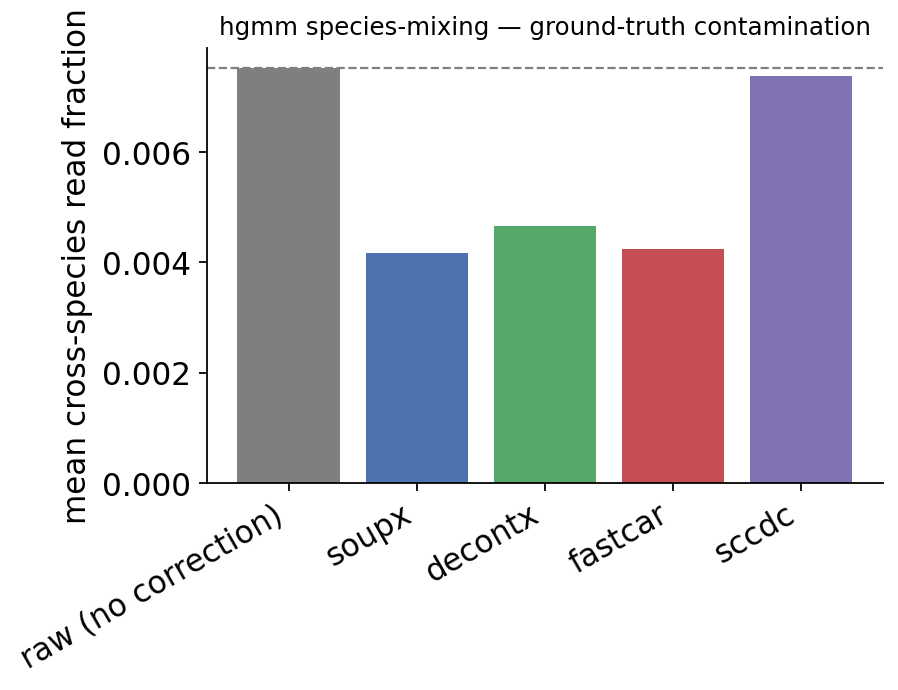

In [26]:
fig, ax = plt.subplots(figsize=(5.5, 4.2), constrained_layout=True)
colors = ["#7f7f7f", "#4C72B0", "#55A868", "#C44E52", "#8172B3"]
ax.bar(gt_df.index, gt_df["mean cross-species fraction"], color=colors)
ax.axhline(gt["raw (no correction)"], ls="--", lw=1, color="#7f7f7f")
ax.set_ylabel("mean cross-species read fraction")
ax.set_title("hgmm species-mixing — ground-truth contamination", fontsize=11)
for tick in ax.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha("right")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

This is the real test: the cross-species read fraction is a quantity no
method can see during fitting, yet every backend **reduces** it. The
empty-droplet methods (SoupX, FastCAR) and the EM model (DecontX) all
strip a substantial share of the wrong-species reads; scCDC, which by
design only touches Global-Contamination-causing Genes, moves it least —
the expected behaviour of a deliberately conservative method.

## 6. Choosing a method

The four native backends — plus the deep-learning options — make
different trade-offs. The research consensus, and the behaviour seen
above:

| Method | Needs | Strengths | Watch out for |
|---|---|---|---|
| **SoupX** | raw matrix + empty droplets; clusters for auto-rho | gentle, interpretable, fast; reads the soup directly from empty droplets | conservative — under-corrects clean datasets |
| **DecontX** | filtered, clustered matrix | no empty droplets required; per-cell variational estimate | can over-correct if clustering is poor |
| **FastCAR** | raw matrix + empty droplets | deterministic per-gene subtraction; very fast | tuned by hard cutoffs (`empty_droplet_cutoff`) |
| **scCDC** | filtered, clustered matrix | anti-over-correction — only fixes contamination-causing genes | corrects few genes; leaves most soup if it is diffuse |
| **CellBender** | raw 10x h5 (GPU) | best overall in benchmarks; jointly calls cells + removes background | heavyweight, GPU, run via its own CLI |
| **scAR** | raw matrix (GPU) | deep ambient denoising | heavyweight, GPU |

Practical guidance:

- **Have empty droplets and want a safe default** — SoupX. It rarely
  hurts and is easy to reason about.
- **Only have a filtered matrix** (a public h5ad, no raw droplets) —
  DecontX or scCDC.
- **Worried about over-correction** of biologically real markers —
  scCDC.
- **Compute budget and a GPU** — CellBender generally wins benchmarks,
  but is heavyweight; `ov.pp.ambient` keeps its wrapper thin and points
  you at CellBender's own `remove-background` CLI, then load the result
  with `ov.read`.

Whatever you pick, **audit it**: `ambient_negative_marker_check`,
`count_integrity_check` and — when you have one — a ground-truth signal
like the cross-species fraction. Then continue the normal workflow
(normalize, HVG, cluster, annotate) on the decontaminated `.X`.